### Stock Market Analysis
        - Abhinav Dubey

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
from datetime import datetime
end = datetime(2024,6,30)
start = datetime(end.year-20, end.month, end.day)


In [3]:
stock = "GOOG"
google_data = yf.download(stock, start, end)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [4]:
google_data.head()


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2004-08-19,2.487352,2.579567,2.378775,2.478923,897427216
2004-08-20,2.684922,2.704009,2.491318,2.503960,458857488
2004-08-23,2.711942,2.813082,2.703266,2.745407,366857939
2004-08-24,2.599647,2.766478,2.567421,2.757554,306396159
2004-08-25,2.627658,2.677237,2.575105,2.601877,184645512


In [5]:
google_data.shape


(4999, 5)

In [6]:
google_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,4999.000000,4999.000000,4999.000000,4999.000000,4.999000e+03
mean,44.487378,44.932449,44.019611,44.462301,1.161724e+08
std,42.341446,42.768171,41.886332,42.295916,1.499679e+08
min,2.479170,2.522056,2.378775,2.458844,1.584340e+05
25%,12.937871,13.072229,12.796201,12.927831,2.747200e+07
50%,26.817505,27.002615,26.626884,26.799566,5.668680e+07
75%,59.691277,60.050328,59.149340,59.591248,1.432268e+08
max,186.190750,186.828457,184.785796,185.054827,1.650833e+09


In [7]:
google_data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4999 entries, 2004-08-19 to 2024-06-28
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   4999 non-null   float64
 1   (High, GOOG)    4999 non-null   float64
 2   (Low, GOOG)     4999 non-null   float64
 3   (Open, GOOG)    4999 non-null   float64
 4   (Volume, GOOG)  4999 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 234.3 KB


In [8]:
google_data.isna().sum()


Price   Ticker
Close   GOOG      0
High    GOOG      0
Low     GOOG      0
Open    GOOG      0
Volume  GOOG      0
dtype: int64

In [9]:
google_data.columns


MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

In [10]:
def plot_graph(figsize, values, column_name):
    plt.figure()
    values.plot(figsize=figsize)
    
    col_label = column_name[0] if isinstance(column_name, tuple) else column_name

    plt.xlabel("Years")
    plt.ylabel(col_label)
    plt.title(f"{col_label} of Google data")
    plt.show()


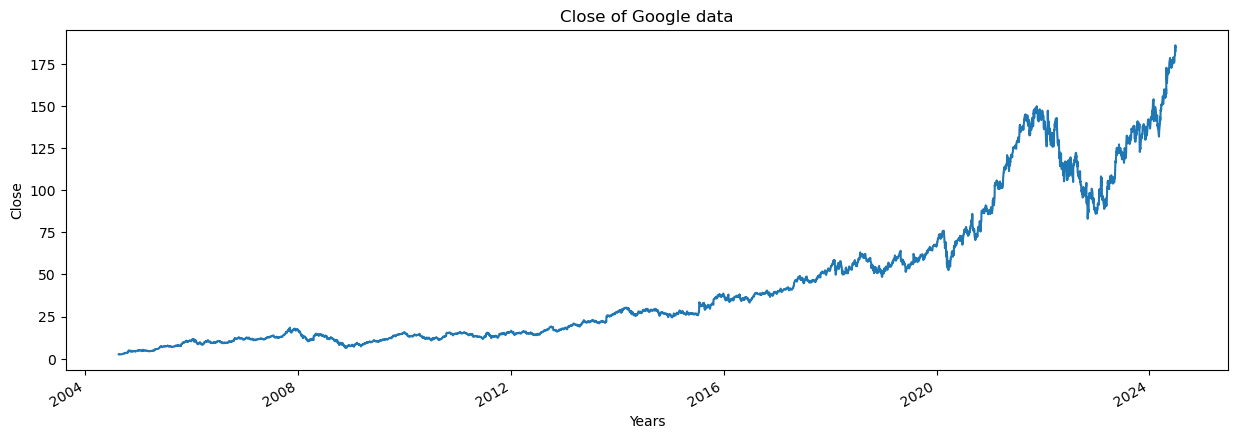

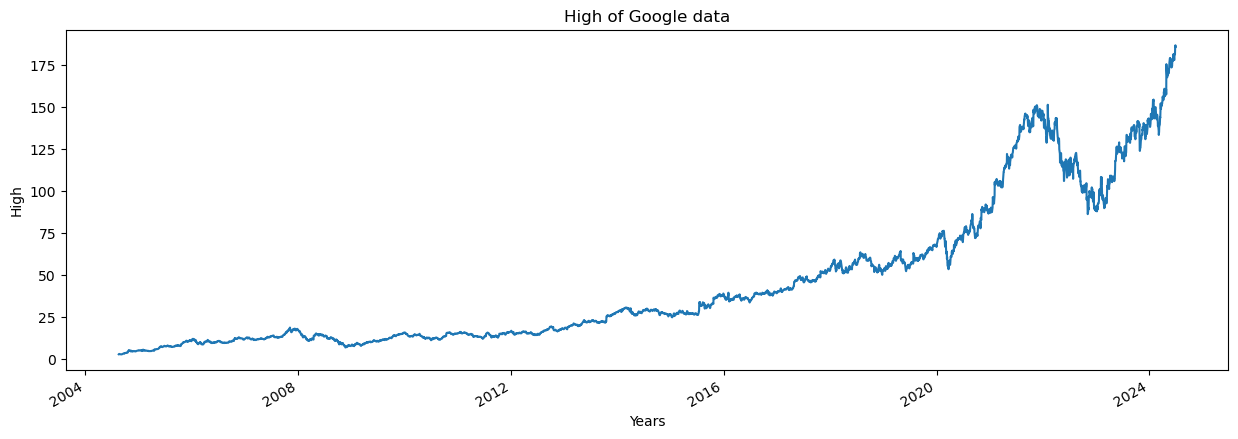

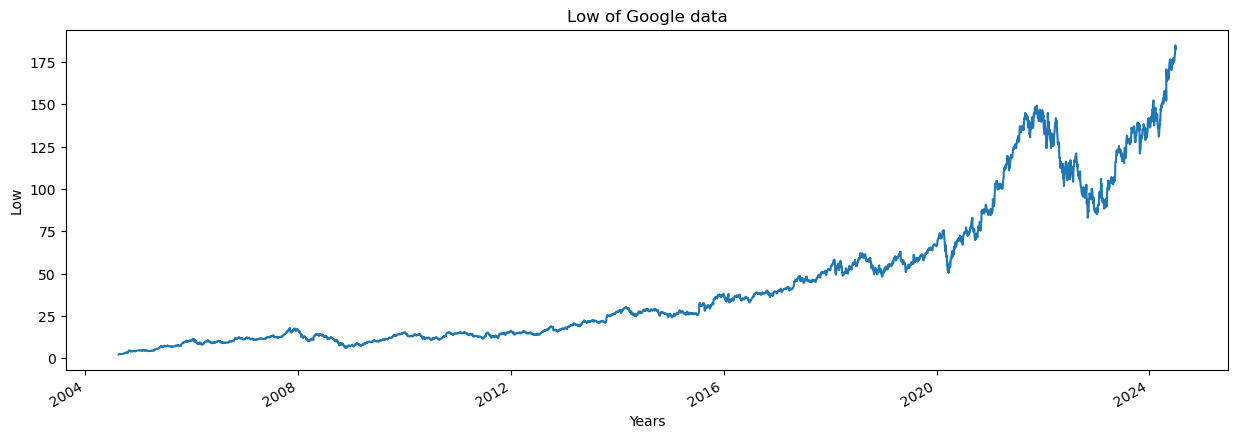

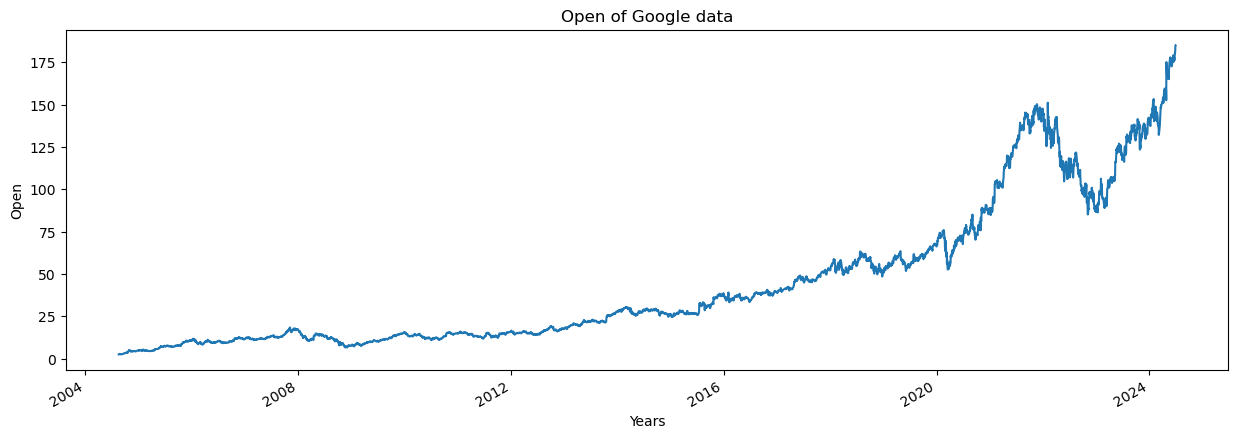

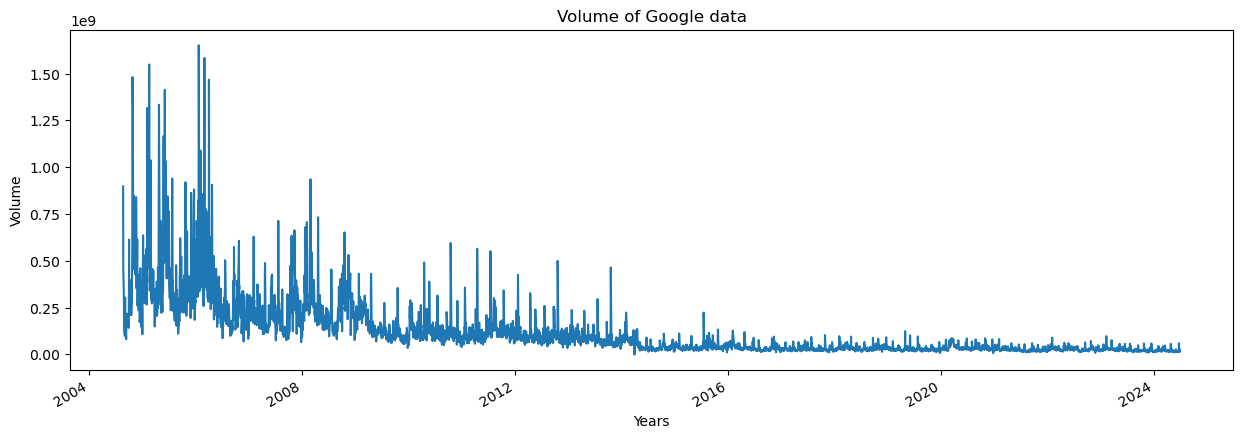

In [11]:
for column in google_data.columns:
    plot_graph((15,5),google_data[column], column)


In [12]:
for i in range(2004,2025):
    print(i,list(google_data.index.year).count(i))

2004 94
2005 252
2006 251
2007 251
2008 253
2009 252
2010 252
2011 252
2012 250
2013 252
2014 252
2015 252
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250
2024 124


In [13]:
google_data['MA_for_250_days'] = google_data['Close'].rolling(250).mean()


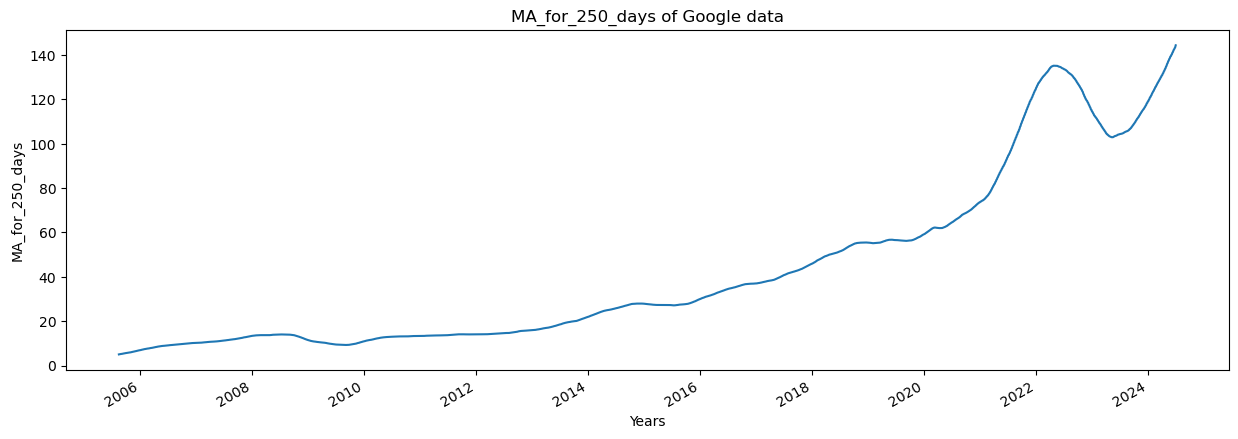

In [14]:
plot_graph((15,5), google_data['MA_for_250_days'], 'MA_for_250_days')


<Figure size 640x480 with 0 Axes>

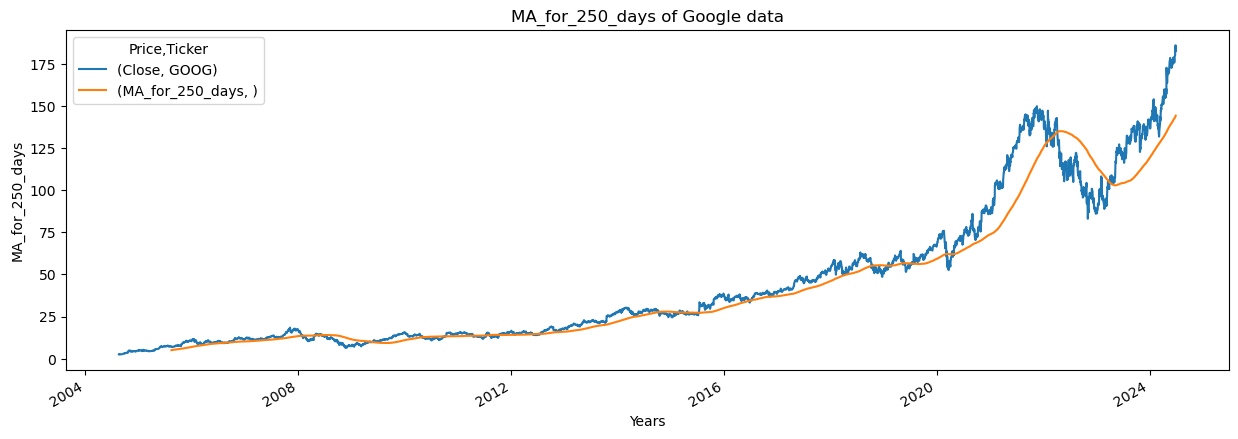

In [15]:
plot_graph((15,5), google_data[['Close','MA_for_250_days']], 'MA_for_250_days')


<Figure size 640x480 with 0 Axes>

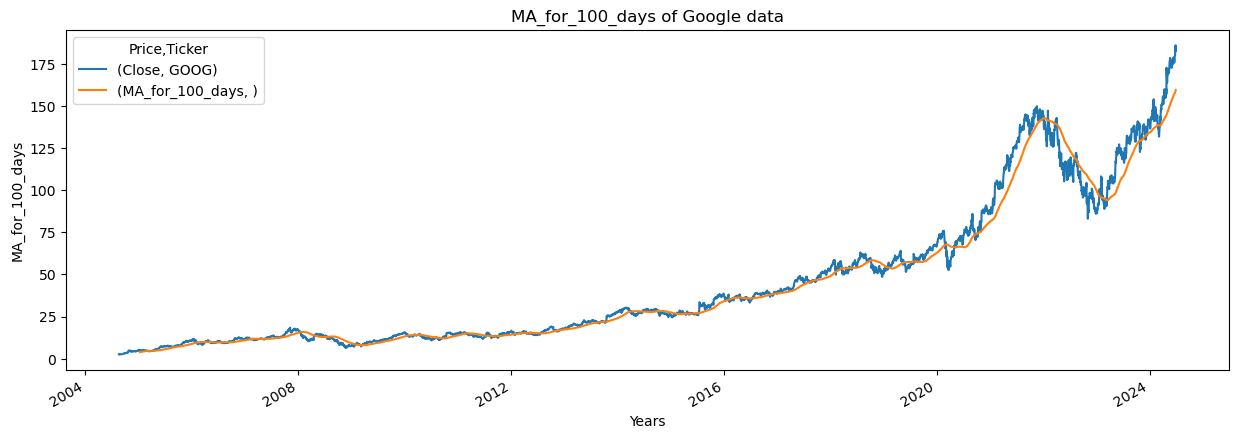

In [16]:

google_data['MA_for_100_days'] = google_data['Close'].rolling(100).mean()
plot_graph((15,5), google_data[['Close','MA_for_100_days']], 'MA_for_100_days')


<Figure size 640x480 with 0 Axes>

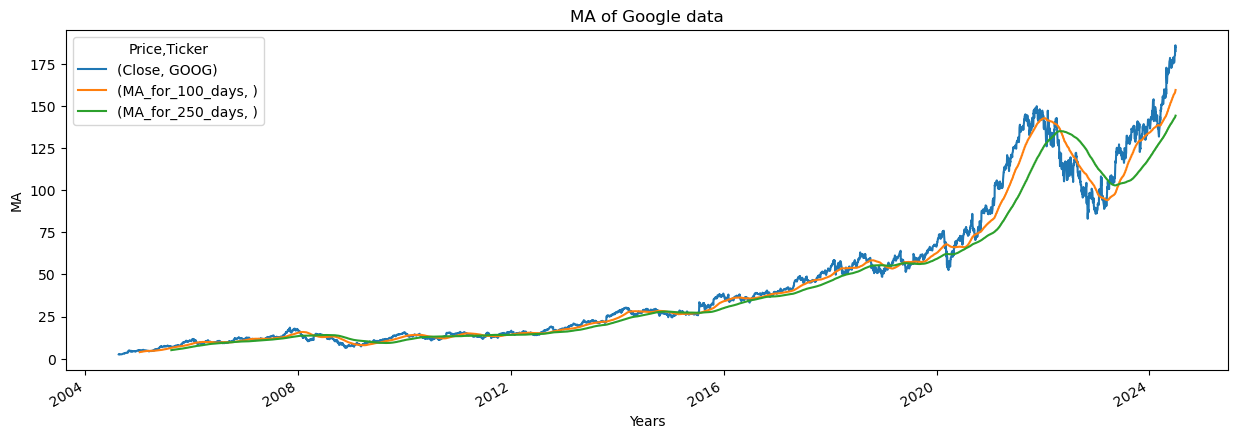

In [17]:
plot_graph((15,5), google_data[['Close','MA_for_100_days', 'MA_for_250_days']], 'MA')


In [18]:
google_data['percentage_change_cp'] = google_data['Close'].pct_change()
google_data[['Close','percentage_change_cp']].head()

Price,Close,percentage_change_cp
Ticker,GOOG,
Date,,
2004-08-19,2.487352,NaN
2004-08-20,2.684922,0.079430
2004-08-23,2.711942,0.010064
2004-08-24,2.599647,-0.041408
2004-08-25,2.627658,0.010775


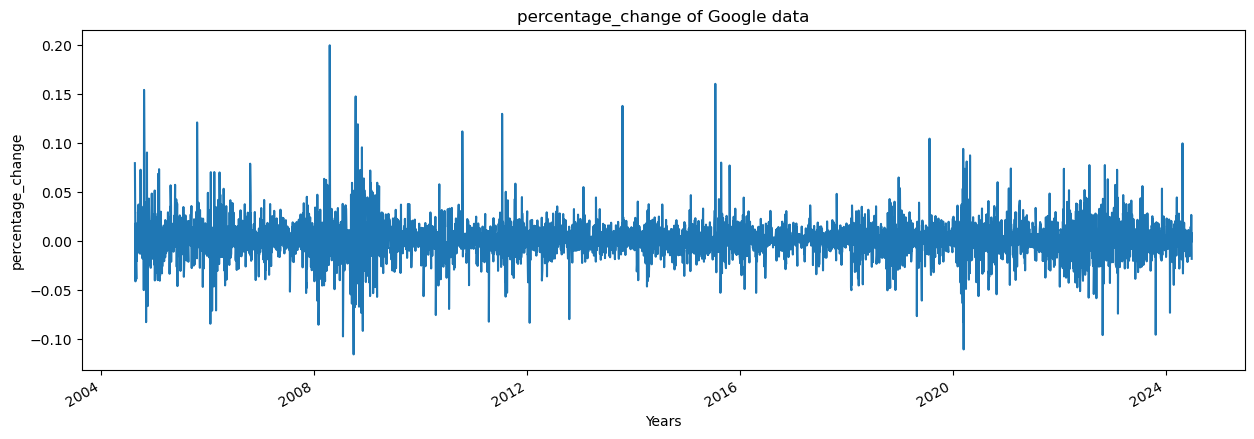

In [19]:
plot_graph((15,5), google_data['percentage_change_cp'], 'percentage_change')


In [20]:
close_price = google_data[['Close']]


In [21]:
max(close_price.values),min(close_price.values) 


(array([186.19075012]), array([2.47917032]))

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_price)
scaled_data

array([[4.45348735e-05],
       [1.11996979e-03],
       [1.26704934e-03],
       ...,
       [9.91918418e-01],
       [1.00000000e+00],
       [9.81342011e-01]])

In [23]:
x_data = []
y_data = []

for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])
    
x_data, y_data = np.array(x_data), np.array(y_data)

In [24]:
len(scaled_data)

4999

In [25]:
int(len(x_data)*0.7)


3429

In [26]:
4999-100-int(len(x_data)*0.7)


1470

In [27]:
split = int(len(x_data)*0.7)
x_train = x_data[:split]
y_train = y_data[:split]

x_test = x_data[split:]
y_test = y_data[split:]

In [28]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3429, 100, 1)
(3429, 1)
(1470, 100, 1)
(1470, 1)


#### Building the model

In [29]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [30]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

C:\Users\abhin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model.compile(optimizer='adam', loss='mean_squared_error')


In [32]:
model.fit(x_train, y_train, batch_size=1, epochs = 1)


3429/3429 ━━━━━━━━━━━━━━━━━━━━ 102s 28ms/step - loss: 2.4208e-04


In [33]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [34]:
predictions = model.predict(x_test)


46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


In [35]:
predictions


array([[0.32242092],
       [0.32302976],
       [0.3250073 ],
       ...,
       [0.9933547 ],
       [1.001301  ],
       [1.0092832 ]], dtype=float32)

In [36]:
inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[ 61.711628],
       [ 61.82348 ],
       [ 62.186775],
       ...,
       [184.96991 ],
       [186.42976 ],
       [187.89616 ]], dtype=float32)

In [37]:
inv_y_test = scaler.inverse_transform(y_test)
inv_y_test

array([[ 60.74478531],
       [ 61.79829407],
       [ 61.2673111 ],
       ...,
       [184.70606995],
       [186.19075012],
       [182.76306152]])

In [38]:
rmse = np.sqrt(np.mean( (inv_predictions - inv_y_test)**2))


In [39]:
rmse

4.547436117724194

In [40]:
ploting_data = pd.DataFrame(
 {
  'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
 } ,
    index = google_data.index[split+100:]
)
ploting_data.head()

,original_test_data,predictions
Date,,
2018-08-24,60.744785,61.711628
2018-08-27,61.798294,61.823479
2018-08-28,61.267311,62.186775
2018-08-29,62.170532,62.494781
2018-08-30,61.663929,62.887112


<Figure size 640x480 with 0 Axes>

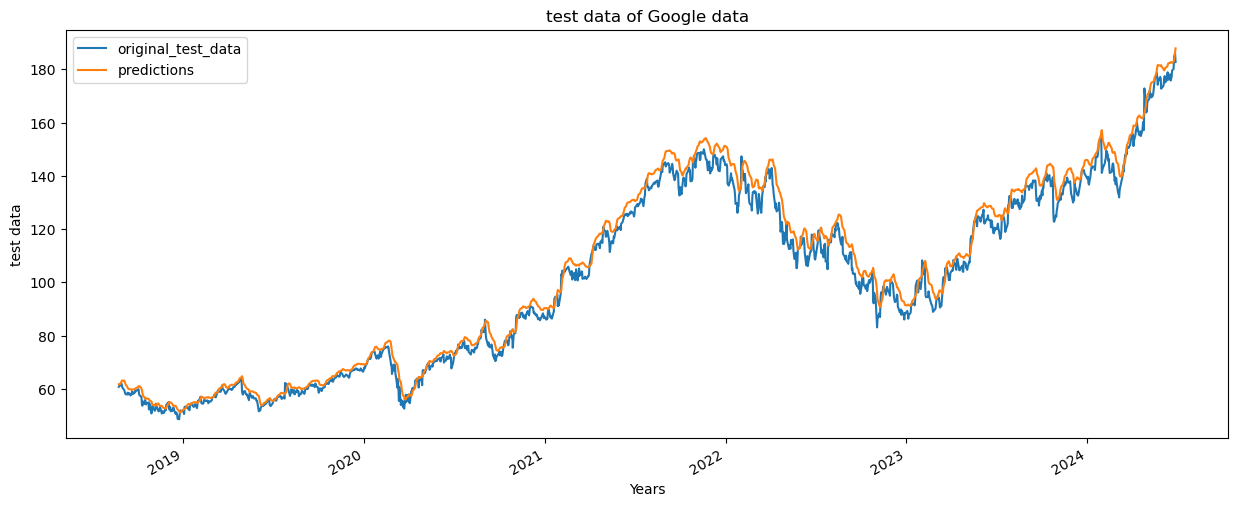

In [41]:
plot_graph((15,6), ploting_data, 'test data')


<Figure size 640x480 with 0 Axes>

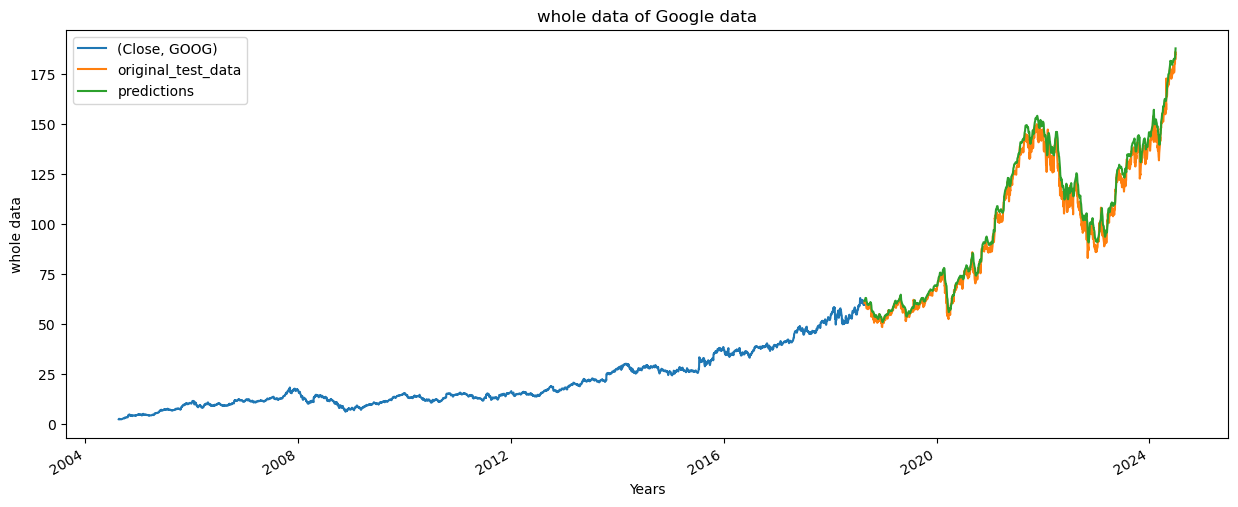

In [42]:
plot_graph((15,6), pd.concat([close_price[:split+100],ploting_data], axis=0), 'whole data')


In [43]:
model.save("Stock_Model.keras")


In [44]:
import tensorflow as tf
print(tf.__version__)


2.18.0
